In [1]:
import sys
sys.path.append("../")

from chic import Structure

import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import HTML

---
# Example 1: coarse-graining ZIF-8

By way of a coarse-graining example, we take the prototypical ZIF-8 structure (CCDC code: VELVOY), average the proton disorder found for the methyl-group protons, and remove the oxygen atoms in the pore. We then `reduce()` the structure to its fundamental building units (Zn A sites and methyl-imidazolate B sites), `coarse_grain()` the structure by placing placeholder atoms at the centroid of each of the B site organic ligands.

Throughout we visualise the crystal structures using ASE's write HTML functionality and using `IPython.display.HTML`. Note this does not account for periodic boundary conditions such that all molecules are "completed", but it serves well for illustrative purposes. Alternatively, you could output the current full-atomistic structure using `Structure.dump(fileName)` and then use your own CIF visualisation software.

In [2]:
# read in CIF and visualise the unit cell. Note the H-disorder and the prescence of non-framework oxygens.
zif8 = Structure("VELVOY.cif")
HTML(zif8.atoms_html())

* sites * A sites: Zn
* sites * B sites: H, C, N, O


---
## `Structure.repair_disorder()`

From the above image, we see the methyl group protons are disordered and there are oxygen atoms in the pores. We "repair" this disorder using the `pairwiseElement` and `loneElement` arguements of the `Structure.repair_disorder()` method. For each of these, we specify the element that we are targetting by its chemical symbol, and give cut-off distances.

For `pairwiseElement` the cut-off can either be a single `float` which specifies the upper limit to consider two atoms of the given element as a disordered pair (lower limit defaults to zero). Alternatively, a `tuple` of `floats` may be given to specify the upper and lower bounds.

In [3]:
# In this ZIF-8 example, the methyl-group protons are disorderd, and there
# are oxygen atoms in the pores. Both of these are "solved" with the following
# two functions.
zif8.repair_disorder("pairwiseElement", element="H", cutoff=(0,0.8))
zif8.repair_disorder("loneElement", element="O", cutoff=2.0)
HTML(zif8.atoms_html())

* disorder * Averaged 72 pairs of H atoms.
* disorder * Deleted 40 O atoms.


---
## `Structure.reduce()`

Next, we identify the buidling units in the structure. We do this by calling the `Structure.reduce()` method. In this example, the structure is relatively "simple" and so the default parameters are suffice. However, for more complicated MOF structures, more care may be needed to be taken to ensure the building units are determined correctly. The following parameters may be tuned for this purpose:

* **skipSites** (default=None)

Skip the cluster-crawl algorithm for a given site-type, and instead iterate through all atoms within this site-type and add them as individual building units. Note, this is the expected behaviour for "single node" representations.

* **intraWeight** (default=0.2)

The CrystalNN neighour searching algorithm gives relative weightings of proposed neighbour atoms. intraWeight sets the minimum weight for a given bond required for it to be considered a bond within the same building unit.

* **interWeight** (default=0.4)

As before, but intraWeight sets the minimum weight required to consider an atom to be a bond between a building unit atom and an atom of another site-type.

* **intraBond** (default=None)

Maximum bond length between two atoms for it to be considered a bond between a building unit atom and an atom of another site-type.

* **interBond** (default=None)

Maximum bond length between two atoms for it to be considered a bond between two building units.

* **cLimit** (default=None)

Maximum connectivity allowed for each site-type (list of ints). If more connections are found than than permitted by cLimit, the connections are ordered by maximum weighting and cut-off at cLimit.

In [4]:
# identify all of the building units (Zn A sites and mIm B sites) using the reduce() command.
zif8.reduce()

* nearest-neighbour * CrystalNN algorithm took 4.456 s.
* reduce * Found 12 A-type building units.
* reduce * Found 24 B-type building units.
* reduce * Reduce algorithm took 0.040 s.


---
After calling `Structure.reduce()`, the `Structure.units` dictionary attribute is now populated with all of the building units found. They will be labelled with a letter corresponding to the site-type (a, b, c, etc.) and a number to distinguish between different units of a given site-type. The `buildingUnit` class (see bu.py) stores information about the molecule's position, bonds, and formula.

By way of an example, if we extract the first building unit of the second site-type ("B") for our ZIF-8 example, we expect to get the methyl-imidazolate ligand (H<sub>3</sub>C-C<sub>3</sub>N<sub>2</sub>H<sub>2</sub>). First of all, let us visualise it in the same way as before.

In [5]:
# visualise an example of the B site building units (print composition and visualise molecule).
bu_b1 = zif8.units["b1"]
HTML(bu_b1.bu_html())

We can also extract other properties about the building unit.

* formula: `buildingUnit.composition()`.
* coordination number: `buildUnit.cn()`

In [6]:
# print formula and connectivity of the building unit.
print(f"Building unit 'b1' formula:\t{bu_b1.composition()}")
print(f"Building unit 'b1' CN:\t\t{bu_b1.cn()}")

Building unit 'b1' formula:	H5 C4 N2
Building unit 'b1' CN:		2


In [7]:
# note, can also get the composition as a Pymatgen Composition object.
# this has other functionality that can be explored; see:
# https://pymatgen.org/pymatgen.core.composition.html
bu_b1.composition(asPymatgen=True)

Comp: H5 C4 N2

---
## `Structure.coarse_grain()`

### (i) centroid

The simplest way of coarse-graining can now be carried out; namely, taking the centroid of the cartesian coordinates for all atoms in the molecule and placing the dummy atom there.

To do this we call `Structure.coarse_grain(method="centroid")`. We can visualise how the coarse-graining has been carried out in CIF format by calling `Structure.overlay(fileName, siteMap)` where the `siteMap = ["Si", "Ce"]` arguement means that all A sites (Zn) will be coarse-grained to "Si" and all B sites (mIm) will be coarse-grained to "Ce". This CIF will display both the original full-atomistic structure and the dummy atoms together.

We can also visualise the HTML-formatted coarse-grained structure as before.

In [8]:
# replace the organic linkers with a placeholder O atom at the centroid
# and set all A sites to Si.
zif8.coarse_grain(method="centroid")

# output CIF with both full-atomistic structure and coarse-grained structure overlaid.
zif8.overlay(f"zif8_overlay_centroid.cif", siteMap=["Si", "Ce"])

# visualise coarse-grained structure.
HTML(zif8.cg_atoms_html(siteMap=["Si", "Li"]))

* coarse-grain * Coarse-grain algorithm took 0.002 s.


In [9]:
# we can also visualise the overlaid structure in HTML form. Here the B sites (large purple) can be seen to be
# in the rings, skewed towards the methyl group substituent.
HTML(zif8.overlay(f"zif8_overlay_centroid.cif", siteMap=["Si", "Li"], return_html=True))

---

### (ii) shortest_path

We store the connectivity (intraBonds) of the building unit as a graph (`buildingUnit.graph`), built on the NetworkX graph object (stored in `buildingUnit.graph.g`). Each node is stored as the index of the atom from the full atomistic structure, and has its chemical symbol stored as a property of the node. We can therefore visualise the graph using `matplotlib.pyplot`.

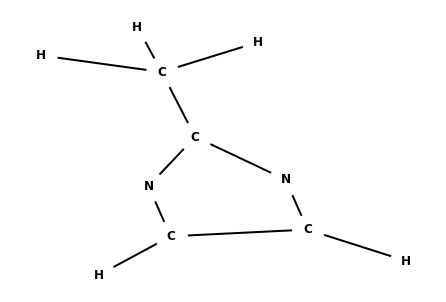

In [10]:
# we can also look at the NetworkX graph for this building unit.

# note: NetworkX visualisation of graphs is only to serve as a rough guide,
# if the molecule is not clear, try re-executing the cell unitl a reasonable
# graph is shown.
options = {
        'node_color': 'white',
        'node_size': 1000,
        'width': 2,
        'font_weight':"bold"
}

nx.draw(bu_b1.graph.g, labels=dict(bu_b1.graph.g.nodes(data="symbol")), **options)
plt.show()

---
From the graph, we can find the shortest path between the "connecting atoms" (i.e. the two N atoms that bond to the Zn atoms in the ZIF framework). Then, we can define a new coarse-grained site as the middle of the path (i.e. on the C bonded to both Ns and the methyl group). If we visualise this coarse-grained structure, we can note the B sites sitting ontop of that carbon. See the CIF outputs to see more clearly.

In [11]:
# replace the organic linkers with a placeholder Ce atom at the centroid
# and set all A sites to Si.
zif8.coarse_grain(method="shortest_path")
zif8.overlay(f"zif8_overlay_shortest_path.cif", siteMap=["Si", "Ce"])

# view HTML structure.
HTML(zif8.overlay(f"zif8_overlay_shortest_path.cif", siteMap=["Si", "Li"], return_html=True))

* coarse-grain * Coarse-grain algorithm took 0.009 s.


---

### (iii) shortest_path with cycles

A third coarse-graining option is to identify the rings (or cycles) within the building unit and use the centroids to define the shortest paths. This can be achieved using `Structure.coarse_grain(method="shortest_path", useCycles=True)`. This algorithm proceeds by:

* identify all simple cycles in the graph;
* contract the cycles to a new single node (cX), and reconnect the "external" nodes that would previously connected to the "internal" nodes in the cycle;
* find the shortest path using the cycle nodes replaced with cX;
* find the middle node(s) of this path. If this corresponds to a cX node, replace with all nodes of original cycle so that the centroid is the average of the cycle.

We can visualise the effect of contracting the cycles in graph form. Here, the new cX node is labelled "X".

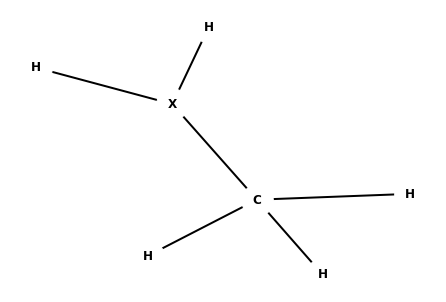

In [12]:
# get contracted cycles graph.
ccg, _ = bu_b1.graph.contracted_cycles
nx.draw(ccg, labels=dict(ccg.nodes(data="symbol")), **options)
plt.show()

In [13]:
# replace the organic linkers with a placeholder Ce atom at the centroid
# of the ring and set all A sites to Si.
zif8.coarse_grain(method="shortest_path", useCycles=True)
zif8.overlay(f"zif8_overlay_shortest_path_rings.cif", siteMap=["Si", "Ce"])

# we can also visualise the overlaid structure in HTML form. Here the B sites (large purple) can be seen to be
# at the centre of the rings, rather than skewed towards the methyl substituent as before.
HTML(zif8.overlay(f"zif8_overlay_centroid.cif", siteMap=["Si", "Li"], return_html=True))

* coarse-grain * Coarse-grain algorithm took 0.018 s.


---
## `Structure.write_cg_cif()`

Finally, once a given coarse-grained procedure has been decided upon (each time `Structure.coarse_grain()` is called, the final coarse-grained positions will be given by the most recent parameters), the structure can be output to a CIF, with the connectivity included according to the topoCIF specification.

The coarse-grained structure can also be scaled to some characteristic bond length by setting the `scale` and `scaleValue` parameters.

In [14]:
# write the coarse-grained structure to a CIF with the TopoCIF data block.
zif8.write_cg_cif("zif8.cif", scale="min_ab", scaleValue=1.0, siteMap=["Si", "O"])

---
## `Structure.get_cg_atoms()`

You can also extract the coarse-grained structure information (optionally with either a Pymatgen `Structure` object or ASE `Atoms` object as well) for subsequent analysis.

In [15]:
# get structure infomration with Pymatgen Structure object.
cg_info, s = zif8.get_cg_atoms(scale="min_ab", siteMap=["Si", "O"], package="pymatgen")

In [16]:
# print out what is contained in cg_info.
cg_info.keys()

dict_keys(['lattice', 'symbols', 'labels', 'frac_coords', 'bonds'])

In [17]:
# print repr for Pymatgen Structure.
print(s)

Full Formula (Si12 O24)
Reduced Formula: SiO2
abc   :   5.380474   5.380474   5.380474
angles:  90.000000  90.000000  90.000000
Sites (36)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Si    0         0.5       0.75
  1  Si    0.5       0         0.75
  2  Si    0.75      0.5       0
  3  Si    0         0.75      0.5
  4  Si    0         0.5       0.25
  5  Si    0.25      0.5       1
  6  Si    0.5       0         0.25
  7  Si    0.5       0.25      1
  8  Si    0         0.25      0.5
  9  Si    0.25      0         0.5
 10  Si    0.75      0         0.5
 11  Si    0.5       0.75      0
 12  O     0.857002  0.551436  0.857002
 13  O     0.551436  0.857002  0.857002
 14  O     0.857002  0.857002  0.551436
 15  O     0.642998  0.642998  0.051436
 16  O     0.642998  0.051436  0.642998
 17  O     0.051436  0.642998  0.642998
 18  O     0.448564  0.857002  0.142998
 19  O     0.857002  0.448564  0.142998
 20  O     0.948564  0.357002  0.642998
 21  